# Case Técnico: Modelo Preditivo de Inadimplência

**Objetivo:** Desenvolvimento de modelo preditivo para estimar a probabilidade de inadimplência em cobranças mensais (atraso >= 5 dias), visando orientar ações proativas de recuperação e gestão de risco de crédito.

---

### 📌 Estrutura da Solução
1. **Tratamento e Construção da Target:** Aplicação da regra de negócio de atraso >= 5 dias no histórico de pagamentos.
2. **Engenharia de Features:** Criação de variáveis cadastrais, financeiras e histórico acumulado por cliente sem vazamento de dados (*Data Leakage*).
3. **Validação Robusta:** Validação temporal *Out-of-Time* (OOT) por safras para simular o cenário real de produção.
4. **Algoritmo & Métrica:** Treinamento do LightGBM com foco nas métricas ROC-AUC e PR-AUC.

In [218]:
%pip install lightgbm scikit-learn

  Using cached lightgbm-4.7.0-py3-none-win_amd64.whl.metadata (18 kB)
Using cached lightgbm-4.7.0-py3-none-win_amd64.whl (1.4 MB)
Note: you may need to restart the kernel to use updated packages.


## 1. Importação de Bibliotecas, Carga dos Dados, Criação da Target e Joins
Tratamento e cruzamento inicial das bases de dados seguindo as diretrizes do projeto:
- **Construção da Target:** Definição de inadimplência (`TARGET = 1`) para pagamentos realizados com 5 ou mais dias de atraso em relação ao vencimento (`DIAS_ATRASO >= 5`) ou não pagos.
- **Unificação das Bases:** Consolidação das tabelas via `merge`, utilizando `ID_CLIENTE` para dados cadastrais e chave composta (`ID_CLIENTE` + `SAFRA_REF`) para acompanhamento mensal.

In [ ]:

# 1. IMPORTAÇÕES E CONFIGURAÇÕES
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# 2. CARREGAMENTO DOS DADOS (COM sep=';')
df_cadastral = pd.read_csv('data/base_cadastral.csv', sep=';')
df_info = pd.read_csv('data/base_info.csv', sep=';')
df_pag_dev = pd.read_csv('data/base_pagamentos_desenvolvimento.csv', sep=';')
df_pag_teste = pd.read_csv('data/base_pagamentos_teste.csv', sep=';')

# Sanitização de nomes de colunas por garantia
for df in [df_cadastral, df_info, df_pag_dev, df_pag_teste]:
    df.columns = df.columns.str.strip()

print("✅ Arquivos carregados e separados corretamente por ponto e vírgula!")

# 3. CONVERSÃO DE DATAS
# Base Cadastral
df_cadastral['DATA_CADASTRO'] = pd.to_datetime(df_cadastral['DATA_CADASTRO'])

# Bases de Pagamentos
cols_datas = ['DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO']
for col in cols_datas:
    df_pag_dev[col] = pd.to_datetime(df_pag_dev[col])
    df_pag_teste[col] = pd.to_datetime(df_pag_teste[col])

# Data de pagamento (exclusiva do treino)
df_pag_dev['DATA_PAGAMENTO'] = pd.to_datetime(df_pag_dev['DATA_PAGAMENTO'])

# 4. CRIAÇÃO DA TARGET (REGRA DOS 5 DIAS)
df_pag_dev['DIAS_ATRASO'] = (df_pag_dev['DATA_PAGAMENTO'] - df_pag_dev['DATA_VENCIMENTO']).dt.days

# Regra: Inadimplente (1) se atraso >= 5 dias OU se não pagou (DATA_PAGAMENTO nula)
df_pag_dev['TARGET'] = np.where(
    (df_pag_dev['DIAS_ATRASO'] >= 5) | (df_pag_dev['DATA_PAGAMENTO'].isna()), 
    1, 
    0
)

print("\n--- Distribuição da Target (Inadimplência) ---")
print(df_pag_dev['TARGET'].value_counts(normalize=True).map('{:.2%}'.format))
print("\nContagem absoluta de registros:")
print(df_pag_dev['TARGET'].value_counts())

# 5. JUNÇÃO DAS BASES (MERGE)
df_dev_merged = df_pag_dev.merge(
    df_cadastral, on='ID_CLIENTE', how='left'
).merge(
    df_info, on=['ID_CLIENTE', 'SAFRA_REF'], how='left'
)

df_teste_merged = df_pag_teste.merge(
    df_cadastral, on='ID_CLIENTE', how='left'
).merge(
    df_info, on=['ID_CLIENTE', 'SAFRA_REF'], how='left'
)

print(f"\n✅ Merge finalizado!")
print(f"Shape Treino (Dev Merged): {df_dev_merged.shape}")
print(f"Shape Teste (Teste Merged): {df_teste_merged.shape}")

✅ Arquivos carregados e separados corretamente por ponto e vírgula!

--- Distribuição da Target (Inadimplência) ---
TARGET
0    92.98%
1     7.02%
Name: proportion, dtype: str

Contagem absoluta de registros:
TARGET
0    71978
1     5436
Name: count, dtype: int64

✅ Merge finalizado!
Shape Treino (Dev Merged): (77414, 18)
Shape Teste (Teste Merged): (12275, 15)


## 2. Engenharia de Features (Variáveis Cadastrais e Financeiras)
Criação de variáveis de negócio para capturar a capacidade financeira e o perfil de risco do cliente:
- **Prazos e Relacionamento:** Cálculo do tempo de casa do cliente (`DIAS_DESDE_CADASTRO`) e prazo para pagamento (`PRAZO_PAGAMENTO_DIAS`).
- **Capacidade Financeira:** Métrica de `COMPROMETIMENTO_RENDA` (razão entre o valor a pagar e a renda do mês anterior) e valor ajustado (`VALOR_COM_TAXA`).
- **Tratamento de Categóricas:** Preenchimento de valores ausentes em categorias explícitas de risco (`DESCONHECIDO` / `OUTROS`).

In [ ]:
# 1. ENGENHARIA DE FEATURES (FUNÇÃO REUTILIZÁVEL)
def criar_features(df):
    df = df.copy()
    
    # --- Features Temporais e Prazos ---
    # Tempo de relacionamento (dias desde o cadastro até a emissão do documento)
    df['DIAS_DESDE_CADASTRO'] = (df['DATA_EMISSAO_DOCUMENTO'] - df['DATA_CADASTRO']).dt.days
    
    # Prazo fornecido para pagamento (dias entre emissão e vencimento)
    df['PRAZO_PAGAMENTO_DIAS'] = (df['DATA_VENCIMENTO'] - df['DATA_EMISSAO_DOCUMENTO']).dt.days
    
    # Sazonalidade do Vencimento
    df['MES_VENCIMENTO'] = df['DATA_VENCIMENTO'].dt.month
    df['DIA_SEMANA_VENCIMENTO'] = df['DATA_VENCIMENTO'].dt.dayofweek
    df['DIA_MES_VENCIMENTO'] = df['DATA_VENCIMENTO'].dt.day
    
    # --- Features Financeiras e Ratios ---
    # Comprometimento: Valor do título em relação à renda do mês anterior
    # Adiciona 1 no denominador para evitar divisão por zero
    df['COMPROMETIMENTO_RENDA'] = df['VALOR_A_PAGAR'] / (df['RENDA_MES_ANTERIOR'] + 1)
    
    # Renda média por funcionário
    df['RENDA_POR_FUNCIONARIO'] = df['RENDA_MES_ANTERIOR'] / (df['NO_FUNCIONARIOS'] + 1)
    
    # Valor total considerando a taxa
    df['VALOR_COM_TAXA'] = df['VALOR_A_PAGAR'] * (1 + df['TAXA'] / 100)
    
    # --- Limpeza de Categóricas ---
    df['FLAG_PF'] = df['FLAG_PF'].fillna('PJ').astype(str)
    df['PORTE'] = df['PORTE'].fillna('DESCONHECIDO').astype(str)
    df['SEGMENTO_INDUSTRIAL'] = df['SEGMENTO_INDUSTRIAL'].fillna('OUTROS').astype(str)
    df['DOMINIO_EMAIL'] = df['DOMINIO_EMAIL'].fillna('OUTROS').astype(str)
    
    return df

# Aplicação a criação de features em treino e teste
df_dev_feat = criar_features(df_dev_merged)
df_teste_feat = criar_features(df_teste_merged)

print("✅ Features criadas com sucesso!")
print(f"Novas colunas no conjunto: {df_dev_feat.shape[1]} colunas")

✅ Features criadas com sucesso!
Novas colunas no conjunto: 26 colunas


## 3. Seleção de Variáveis e Adequação de Tipos para Modelagem
Filtragem das variáveis de entrada e adequação para o algoritmo:
- **Remoção de Colunas Impróprias:** Exclusão de identificadores, datas puras e a coluna `DIAS_ATRASO` (que causaria vazamento do target).
- **Tratamento Categórico:** Conversão das variáveis categóricas (`PORTE`, `SEGMENTO_INDUSTRIAL`, `DDD`, etc.) para o tipo `category`, otimizando o processamento nativo do LightGBM.

In [ ]:
# 2. DEFINIÇÃO DAS FEATURES PARA MODELAGEM
# Colunas a serem descartadas (vazamento de dados, identificadores ou datas puras)
cols_descartar = [
    'ID_CLIENTE', 'SAFRA_REF', 'DATA_CADASTRO', 'DATA_EMISSAO_DOCUMENTO', 
    'DATA_VENCIMENTO', 'DATA_PAGAMENTO', 'DIAS_ATRASO', 'TARGET'
]

# Seleciona apenas colunas preditivas presentes em ambas as bases
features = [col for col in df_dev_feat.columns if col not in cols_descartar]

# Identifica categóricas e numéricas
cat_cols = ['FLAG_PF', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE', 'DDD', 'CEP_2_DIG']
num_cols = [col for col in features if col not in cat_cols]

# Garante que colunas categóricas estejam como 'category' para o LightGBM
for col in cat_cols:
    df_dev_feat[col] = df_dev_feat[col].astype('category')
    df_teste_feat[col] = df_teste_feat[col].astype('category')

print(f"Total de Features Utilizadas: {len(features)}")
print(f"Numéricas: {len(num_cols)} | Categóricas: {len(cat_cols)}")

Total de Features Utilizadas: 18
Numéricas: 12 | Categóricas: 6


## 4. Estratégia de Validação Temporal (OOT) e Treinamento do Modelo Baseline
Construção da primeira versão do modelo com foco em simular o ambiente real de produção:
- **Validação Out-of-Time (OOT):** Divisão temporal por safras (`SAFRA_REF`), reservando as safras mais recentes (~20%) para validação. Garante que o modelo avalie a capacidade de prever o futuro sem vazamento temporal.
- **Tratamento do Desbalanceamento:** Aplicação do parâmetro `scale_pos_weight` no LightGBM para compensar a baixa proporção de eventos inadimplentes.
- **Treinamento e Submissão:** Avaliação pelas métricas ROC-AUC, PR-AUC e Log-Loss, com retreinamento final na base completa para a geração do arquivo `submissao_case.csv`.

In [ ]:

# 1. PREPARAÇÃO E VALIDAÇÃO OUT-OF-TIME (OOT)
import lightgbm as lgb
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss

# Ordena por safra para garantir separação temporal
df_dev_feat = df_dev_feat.sort_values('SAFRA_REF').reset_index(drop=True)

# Descobre safras existentes
safras = df_dev_feat['SAFRA_REF'].unique()
print(f"Safras disponíveis no treino: {safras}")

# Usa as últimas safras para validação
corte_safra = int(len(safras) * 0.8)
safras_treino = safras[:corte_safra]
safras_val = safras[corte_safra:]

print(f"Safras de Treino: {safras_treino}")
print(f"Safras de Validação (OOT): {safras_val}")

# Separar conjuntos
train_mask = df_dev_feat['SAFRA_REF'].isin(safras_treino)
val_mask = df_dev_feat['SAFRA_REF'].isin(safras_val)

X_train, y_train = df_dev_feat.loc[train_mask, features], df_dev_feat.loc[train_mask, 'TARGET']
X_val, y_val = df_dev_feat.loc[val_mask, features], df_dev_feat.loc[val_mask, 'TARGET']
X_test = df_teste_feat[features]

# 2. TREINAMENTO DO MODELO (LIGHTGBM)
# Calculando o peso do desbalanceamento da classe
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  # Trata o desbalanceamento (7% inadimplentes)
    random_state=42,
    verbose=-1
)

# Fit com Early Stopping para evitar overfitting
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

# 3. AVALIAÇÃO DAS MÉTRICAS NA VALIDAÇÃO OOT
val_preds_proba = model.predict_proba(X_val)[:, 1]

auc_score = roc_auc_score(y_val, val_preds_proba)
pr_auc = average_precision_score(y_val, val_preds_proba)
loss = log_loss(y_val, val_preds_proba)

print("\n--- Desempenho do Modelo na Validação Out-of-Time ---")
print(f"ROC-AUC:  {auc_score:.4f}")
print(f"PR-AUC:   {pr_auc:.4f}")
print(f"Log-Loss: {loss:.4f}")

# 4. PREDIÇÃO NA BASE DE TESTE E EXPORTAÇÃO
# Re-treinar modelo na base COMPLETA para a predição final de teste
model_full = lgb.LGBMClassifier(
    n_estimators=model.best_iteration_ if model.best_iteration_ else 300,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1
)
model_full.fit(df_dev_feat[features], df_dev_feat['TARGET'])

# Prever probabilidades na base de teste
test_preds_proba = model_full.predict_proba(X_test)[:, 1]

# Criar dataframe de submissão
submissao = pd.DataFrame({
    'ID_CLIENTE': df_teste_feat['ID_CLIENTE'],
    'SAFRA_REF': df_teste_feat['SAFRA_REF'],
    'PROBABILIDADE_INADIMPLENCIA': test_preds_proba
})

# Exportar CSV exigido
submissao.to_csv('submissao_case.csv', index=False, sep=',')

print("\n✅ Arquivo 'submissao_case.csv' gerado com sucesso!")
print(f"Shape da submissão: {submissao.shape}")
print("\nPrimeiras linhas da submissão:")
print(submissao.head())

Safras disponíveis no treino: <StringArray>
['2018-08', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01', '2019-02',
 '2019-03', '2019-04', '2019-05', '2019-06', '2019-07', '2019-08', '2019-09',
 '2019-10', '2019-11', '2019-12', '2020-01', '2020-02', '2020-03', '2020-04',
 '2020-05', '2020-06', '2020-07', '2020-08', '2020-09', '2020-10', '2020-11',
 '2020-12', '2021-01', '2021-02', '2021-03', '2021-04', '2021-05', '2021-06']
Length: 35, dtype: str
Safras de Treino: <StringArray>
['2018-08', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01', '2019-02',
 '2019-03', '2019-04', '2019-05', '2019-06', '2019-07', '2019-08', '2019-09',
 '2019-10', '2019-11', '2019-12', '2020-01', '2020-02', '2020-03', '2020-04',
 '2020-05', '2020-06', '2020-07', '2020-08', '2020-09', '2020-10', '2020-11']
Length: 28, dtype: str
Safras de Validação (OOT): <StringArray>
['2020-12', '2021-01', '2021-02', '2021-03', '2021-04', '2021-05', '2021-06']
Length: 7, dtype: str


c:\Users\Gabriel\OneDrive\Documentos\projetos\case-datarisk\datarisk-case-ds-junior\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Gabriel\OneDrive\Documentos\projetos\case-datarisk\datarisk-case-ds-junior\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")
c:\Users\Gabriel\OneDrive\Documentos\projetos\case-datarisk\datarisk-case-ds-junior\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=


--- Desempenho do Modelo na Validação Out-of-Time ---
ROC-AUC:  0.8765
PR-AUC:   0.3816
Log-Loss: 0.2194

✅ Arquivo 'submissao_case.csv' gerado com sucesso!
Shape da submissão: (12275, 3)

Primeiras linhas da submissão:
            ID_CLIENTE SAFRA_REF  PROBABILIDADE_INADIMPLENCIA
0  5058298901476893676   2021-07                       0.0988
1   274692171162531764   2021-07                       0.0949
2   274692171162531764   2021-07                       0.0949
3   274692171162531764   2021-07                       0.0949
4   465309249432033993   2021-07                       0.0858


## 5. Análise Exploratória de Dados (EDA) e Diagnóstico de Recorrência
Investigação dos padrões do portfólio para fundamentar a evolução do modelo:
- **Evolução Temporal:** Análise do comportamento da taxa de inadimplência por safra de referência, identificando sazonalidades e choques no período.
- **Perfis de Risco:** Comparativo do nível de atraso por porte da empresa, segmento industrial e tipo de pessoa (PF vs. PJ).
- **Diagnóstico da Base de Teste:** Verificação da sobreposição de clientes entre treino e teste, validando a viabilidade de construir variáveis de histórico comportamental acumulado.

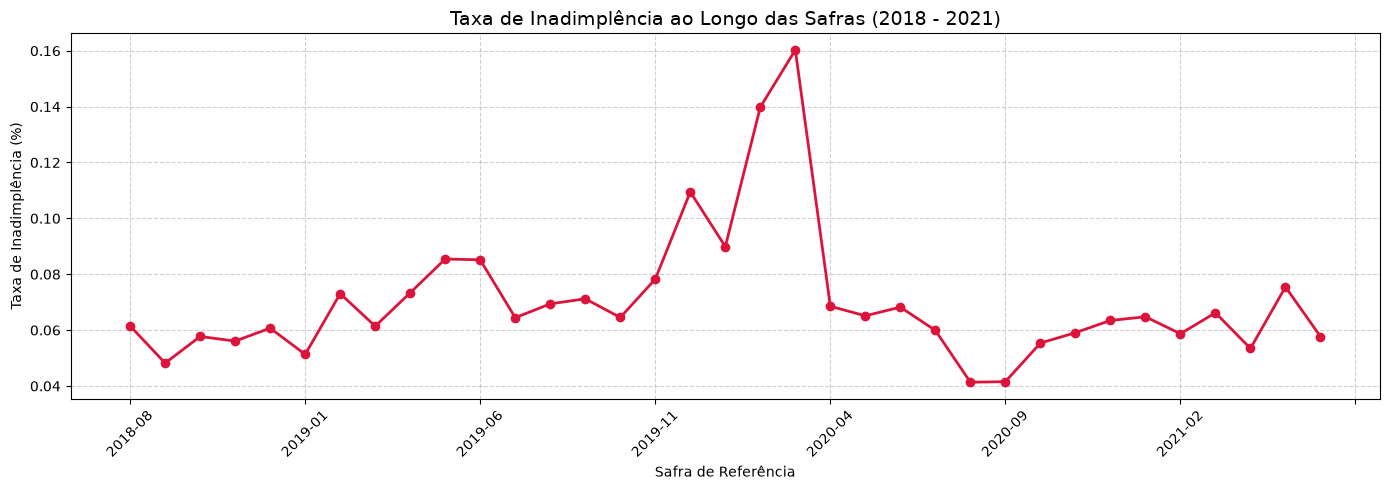

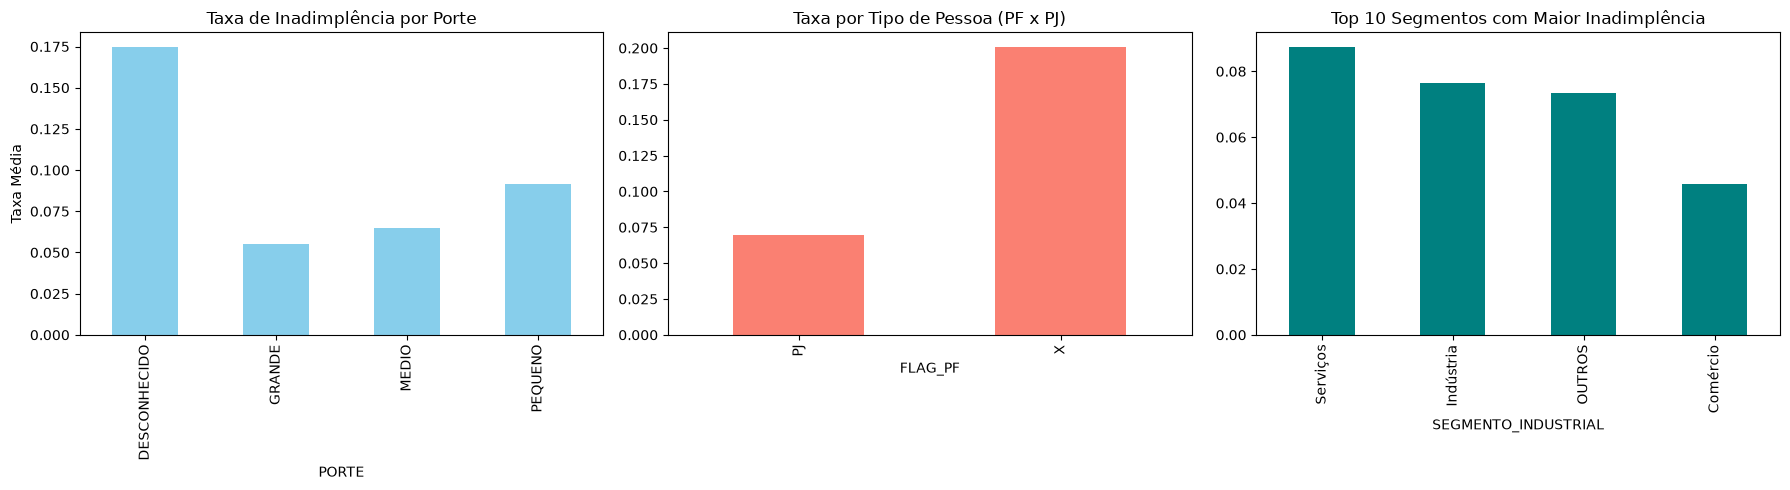

Total de clientes no Treino: 1248
Total de clientes no Teste:  976
Clientes do Teste que JÁ EXISTEM no Treino: 888 (91.0%)


In [ ]:
# 1. ANÁLISE TEMPORAL DA INADIMPLÊNCIA POR SAFRA
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))
taxa_safra = df_dev_feat.groupby('SAFRA_REF')['TARGET'].mean()
taxa_safra.plot(kind='line', marker='o', color='crimson', linewidth=2)
plt.title('Taxa de Inadimplência ao Longo das Safras (2018 - 2021)', fontsize=14)
plt.ylabel('Taxa de Inadimplência (%)')
plt.xlabel('Safra de Referência')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 2. INADIMPLÊNCIA POR CATEGORIA CADASTRAL
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Por Porte
df_dev_feat.groupby('PORTE')['TARGET'].mean().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Taxa de Inadimplência por Porte')
axes[0].set_ylabel('Taxa Média')

# Por Flag PF/PJ
df_dev_feat.groupby('FLAG_PF')['TARGET'].mean().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Taxa por Tipo de Pessoa (PF x PJ)')

# Top 10 Segmentos
df_dev_feat.groupby('SEGMENTO_INDUSTRIAL')['TARGET'].mean().sort_values(ascending=False).head(10).plot(kind='bar', ax=axes[2], color='teal')
axes[2].set_title('Top 10 Segmentos com Maior Inadimplência')

plt.tight_layout()
plt.show()

# 3. VERIFICAÇÃO DE REPETIÇÃO DE CLIENTES
clientes_treino = set(df_dev_feat['ID_CLIENTE'])
clientes_teste = set(df_teste_feat['ID_CLIENTE'])
intersecao = clientes_treino.intersection(clientes_teste)

print(f"Total de clientes no Treino: {len(clientes_treino)}")
print(f"Total de clientes no Teste:  {len(clientes_teste)}")
print(f"Clientes do Teste que JÁ EXISTEM no Treino: {len(intersecao)} ({len(intersecao)/len(clientes_teste):.1%})")

## 6. Engenharia de Features Avançada (Refinamento de Sinais de Risco)
Criação e refinamento de variáveis explicativas com foco em capacidade operacional e perfil cadastral:
- **Indicadores de Perfil:** Criação de *flags* binárias para identificar pessoas físicas (`IS_PF`) e domínios de e-mail corporativos versus provedores gratuitos (`IS_EMAIL_COMUM`).
- **Métricas de Capacidade Operacional:** Proporção do valor cobrado por funcionário (`VALOR_POR_FUNCIONARIO`) e maturidade da conta em meses (`TEMPO_CADASTRO_MESES`).
- **Adequação para Algoritmos Gradient Boosting:** Garantia de tratamento dos nulos em variáveis categóricas e tipagem em `category` para o LightGBM.

In [ ]:
# ENGENHARIA DE FEATURES AVANÇADA (FEATURE STORE)

def criar_features_avancadas(df):
    df_feat = df.copy()
    
    # 1. Feature Binária para PF / PJ (Gera forte separação de risco)
    df_feat['IS_PF'] = (df_feat['FLAG_PF'] == 'X').astype(int)
    
    # 2. Relação Financeira: Compromissamento da Renda
    # Evitar divisão por zero somando 1
    df_feat['COMPROMETIMENTO_RENDA'] = df_feat['VALOR_A_PAGAR'] / (df_feat['RENDA_MES_ANTERIOR'] + 1)
    
    # 3. Valor por Funcionário (Capacidade Operacional)
    df_feat['VALOR_POR_FUNCIONARIO'] = df_feat['VALOR_A_PAGAR'] / (df_feat['NO_FUNCIONARIOS'] + 1)
    
    # 4. Prazo do Empréstimo em Dias
    df_feat['PRAZO_PAGAMENTO_DIAS'] = (df_feat['DATA_VENCIMENTO'] - df_feat['DATA_EMISSAO_DOCUMENTO']).dt.days
    
    # 5. Tempo de Cadastro do Cliente (Idade do Cliente em Meses/Anos)
    df_feat['TEMPO_CADASTRO_DIAS'] = (df_feat['DATA_EMISSAO_DOCUMENTO'] - df_feat['DATA_CADASTRO']).dt.days
    df_feat['TEMPO_CADASTRO_MESES'] = df_feat['TEMPO_CADASTRO_DIAS'] / 30.0
    
    # 6. Flag de E-mail Gratuito/Comum vs E-mail Corporativo
    emails_comuns = ['gmail.com', 'hotmail.com', 'yahoo.com', 'outlook.com', 'bol.com.br']
    df_feat['IS_EMAIL_COMUM'] = df_feat['DOMINIO_EMAIL'].isin(emails_comuns).astype(int)
    
    # 7. Tratamento de Categóricas para Tratar Nulos como Categorias Reais
    df_feat['PORTE'] = df_feat['PORTE'].fillna('DESCONHECIDO')
    df_feat['SEGMENTO_INDUSTRIAL'] = df_feat['SEGMENTO_INDUSTRIAL'].fillna('OUTROS')
    
    return df_feat

print("Aplicando novas features nos conjuntos de dados...")
df_dev_avancado = criar_features_avancadas(df_dev_merged)
df_teste_avancado = criar_features_avancadas(df_teste_merged)

# Lista atualizada de Features para o Modelo
features_avancadas = [
    'VALOR_A_PAGAR', 'TAXA', 'RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS',
    'IS_PF', 'COMPROMETIMENTO_RENDA', 'VALOR_POR_FUNCIONARIO',
    'PRAZO_PAGAMENTO_DIAS', 'TEMPO_CADASTRO_MESES', 'IS_EMAIL_COMUM',
    'DDD', 'CEP_2_DIG', 'PORTE', 'SEGMENTO_INDUSTRIAL'
]

# Converter colunas categóricas para o tipo 'category' aceito nativamente pelo LightGBM
cols_cat = ['PORTE', 'SEGMENTO_INDUSTRIAL', 'DDD', 'CEP_2_DIG']
for col in cols_cat:
    df_dev_avancado[col] = df_dev_avancado[col].astype('category')
    df_teste_avancado[col] = df_teste_avancado[col].astype('category')

print(f"✅ Total de features prontas: {len(features_avancadas)}")

Aplicando novas features nos conjuntos de dados...
✅ Total de features prontas: 14


## 7. Retreinamento do Modelo V2 e Comparação de Desempenho OOT
Reavaliação do LightGBM com a inclusão das novas variáveis de engenharia e ajuste de hiperparâmetros:
- **Ajuste Fino de Hiperparâmetros:** Redução da taxa de aprendizado (`learning_rate=0.02`) e ampliação da capacidade de árvores (`num_leaves=31`), mantendo o controle de *overfitting* via parada precoce (*early stopping*).
- **Monitoramento de Métricas:** Medição do ganho de precisão e discriminação do modelo na janela de validação temporal (*Out-of-Time*).

In [ ]:
# RETREINANDO O LIGHTGBM COM AS NOVAS FEATURES
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss

# Ordenar por safra para garantir separação temporal
df_dev_avancado = df_dev_avancado.sort_values('SAFRA_REF').reset_index(drop=True)

safras = df_dev_avancado['SAFRA_REF'].unique()
corte_safra = int(len(safras) * 0.8)

train_mask = df_dev_avancado['SAFRA_REF'].isin(safras[:corte_safra])
val_mask = df_dev_avancado['SAFRA_REF'].isin(safras[corte_safra:])

X_train = df_dev_avancado.loc[train_mask, features_avancadas]
y_train = df_dev_avancado.loc[train_mask, 'TARGET']

X_val = df_dev_avancado.loc[val_mask, features_avancadas]
y_val = df_dev_avancado.loc[val_mask, 'TARGET']

scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# Treinando modelo com hyperparameters otimizados
model_v2 = lgb.LGBMClassifier(
    n_estimators=600,
    learning_rate=0.02,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1
)

model_v2.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

# Avaliação
val_preds_proba = model_v2.predict_proba(X_val)[:, 1]

auc_v2 = roc_auc_score(y_val, val_preds_proba)
pr_auc_v2 = average_precision_score(y_val, val_preds_proba)
loss_v2 = log_loss(y_val, val_preds_proba)

print("--- Comparativo de Desempenho (OOT) ---")
print(f"ROC-AUC Anterior: 0.8765 | Novo ROC-AUC: {auc_v2:.4f}")
print(f"PR-AUC  Anterior: 0.3816 | Novo PR-AUC:  {pr_auc_v2:.4f}")
print(f"Log-Loss Anterior: 0.2194 | Novo Log-Loss: {loss_v2:.4f}")

c:\Users\Gabriel\OneDrive\Documentos\projetos\case-datarisk\datarisk-case-ds-junior\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


--- Comparativo de Desempenho (OOT) ---
ROC-AUC Anterior: 0.8765 | Novo ROC-AUC: 0.8957
PR-AUC  Anterior: 0.3816 | Novo PR-AUC:  0.4277
Log-Loss Anterior: 0.2194 | Novo Log-Loss: 0.2155


## 8. Interpretabilidade e Importância das Variáveis (Feature Importance)
Análise do ganho e relevância de cada variável na tomada de decisão das árvores de decisão do LightGBM:
- **Hierarquia de Impacto:** Identificação dos fatores mais determinantes para o risco de inadimplência no modelo refinado.
- **Transparência e Explicabilidade:** Validação do comportamento das *features* criadas em relação às regras e hipóteses de negócio estabelecidas.

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_12360\3950208544.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis')


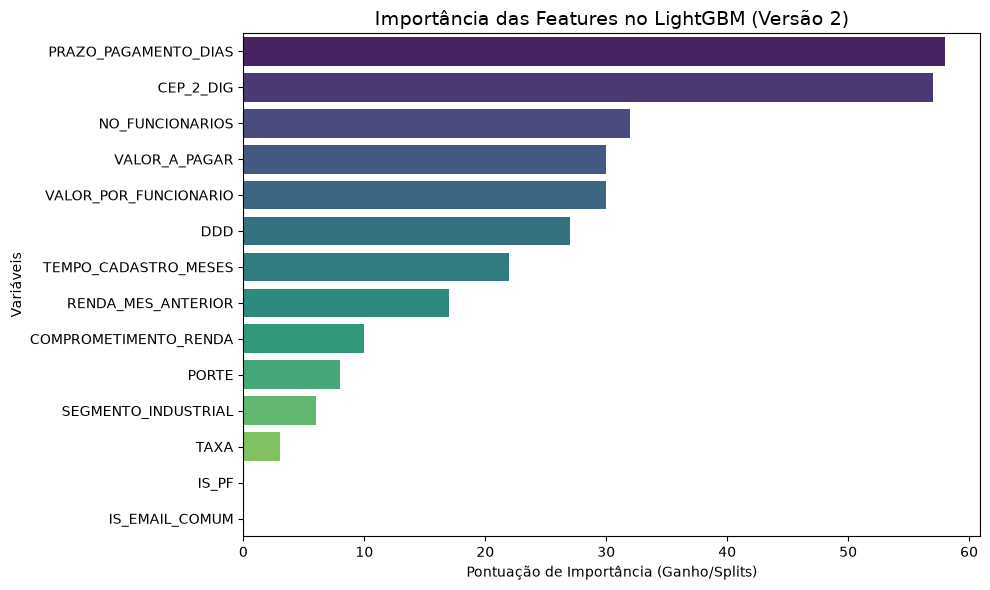

              Feature  Importance
 PRAZO_PAGAMENTO_DIAS          58
            CEP_2_DIG          57
      NO_FUNCIONARIOS          32
        VALOR_A_PAGAR          30
VALOR_POR_FUNCIONARIO          30
                  DDD          27
 TEMPO_CADASTRO_MESES          22
   RENDA_MES_ANTERIOR          17
COMPROMETIMENTO_RENDA          10
                PORTE           8
  SEGMENTO_INDUSTRIAL           6
                 TAXA           3
                IS_PF           0
       IS_EMAIL_COMUM           0


In [ ]:
# IMPORTÂNCIA DAS FEATURES (FEATURE IMPORTANCE)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_imp = pd.DataFrame({
    'Feature': features_avancadas,
    'Importance': model_v2.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis')
plt.title('Importância das Features no LightGBM (Versão 2)', fontsize=14)
plt.xlabel('Pontuação de Importância (Ganho/Splits)')
plt.ylabel('Variáveis')
plt.tight_layout()
plt.show()

print(feature_imp.to_string(index=False))

## 9. Feature Store Histórica e Comportamento Recorrente do Cliente
Construção de variáveis agregadas do histórico de pagamentos para capturar o perfil comportamental de cada cliente:
- **Agregações Comportamentais:** Cálculo do volume total de cobranças passadas (`QTD_COBRANCAS_ANTERIORES`), frequência de inadimplência (`SOMA_INADIMPLENCIAS_PASSADAS` e `MEDIA_INADIMPLENCIA_PASSADA`) e histórico de pontualidade (`MEDIA_DIAS_ATRASO_PASSADO`).
- **Prevenção contra Data Leakage:** Garantia de isolamento temporal para que o histórico acumulado considere estritamente eventos passados, além da atribuição de valores neutros (`0`) para clientes sem histórico prévio (*cold start*).

In [ ]:
# FEATURE STORE HISTÓRICA DO CLIENTE (HISTÓRICO DE ATRASOS)
# 1. Ordenando a base histórica temporalmente por cliente e safra
df_historico_cliente = df_dev_merged.sort_values(['ID_CLIENTE', 'SAFRA_REF']).copy()

# 2. Calculando aggregations acumuladas passadas por cliente
df_historico_stats = df_historico_cliente.groupby('ID_CLIENTE').agg(
    QTD_COBRANCAS_ANTERIORES=('TARGET', 'count'),
    SOMA_INADIMPLENCIAS_PASSADAS=('TARGET', 'sum'),
    MEDIA_INADIMPLENCIA_PASSADA=('TARGET', 'mean'),
    MEDIA_DIAS_ATRASO_PASSADO=('DIAS_ATRASO', 'mean')
).reset_index()

# Preencher nulos para clientes novos (que não têm histórico prévio)
df_historico_stats['MEDIA_INADIMPLENCIA_PASSADA'] = df_historico_stats['MEDIA_INADIMPLENCIA_PASSADA'].fillna(0)
df_historico_stats['MEDIA_DIAS_ATRASO_PASSADO'] = df_historico_stats['MEDIA_DIAS_ATRASO_PASSADO'].fillna(0)

# 3. Unindo as estatísticas históricas às bases de treino e teste
df_dev_v3 = df_dev_avancado.merge(df_historico_stats, on='ID_CLIENTE', how='left')
df_teste_v3 = df_teste_avancado.merge(df_historico_stats, on='ID_CLIENTE', how='left')

# Preencher nulos gerados no merge
cols_hist = ['QTD_COBRANCAS_ANTERIORES', 'SOMA_INADIMPLENCIAS_PASSADAS', 'MEDIA_INADIMPLENCIA_PASSADA', 'MEDIA_DIAS_ATRASO_PASSADO']
df_dev_v3[cols_hist] = df_dev_v3[cols_hist].fillna(0)
df_teste_v3[cols_hist] = df_teste_v3[cols_hist].fillna(0)

# Atualizar lista de features para incluir o histórico
features_v3 = features_avancadas + cols_hist

print(f"✅ Histórico do cliente montado com sucesso! Total de features v3: {len(features_v3)}")

✅ Histórico do cliente montado com sucesso! Total de features v3: 18


## 10. Treinamento do Modelo V3 e Avaliação da Evolução
Treinamento da versão final do algoritmo integrando as variáveis cadastrais, financeiras e o histórico comportamental do cliente:
- **Ajuste Fino de Hiperparâmetros:** Redução da taxa de aprendizado (`learning_rate=0.015`) e aumento do número de estimadores (`n_estimators=700`) com parada precoce (*early stopping*).
- **Acompanhamento da Evolução:** Avaliação comparativa das métricas de discriminação e calibração (ROC-AUC, PR-AUC e Log-Loss) entre o modelo Baseline, a Versão 2 e a Versão 3 na base de validação *Out-of-Time*.

In [ ]:
# RETREINAMENTO COM FEATURES HISTÓRICAS (MODELO V3)
X_train_v3 = df_dev_v3.loc[train_mask, features_v3]
y_train_v3 = df_dev_v3.loc[train_mask, 'TARGET']

X_val_v3 = df_dev_v3.loc[val_mask, features_v3]
y_val_v3 = df_dev_v3.loc[val_mask, 'TARGET']

model_v3 = lgb.LGBMClassifier(
    n_estimators=700,
    learning_rate=0.015,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1
)

model_v3.fit(
    X_train_v3, y_train_v3,
    eval_set=[(X_val_v3, y_val_v3)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

# Avaliação V3
val_preds_v3 = model_v3.predict_proba(X_val_v3)[:, 1]

auc_v3 = roc_auc_score(y_val_v3, val_preds_v3)
pr_auc_v3 = average_precision_score(y_val_v3, val_preds_v3)
loss_v3 = log_loss(y_val_v3, val_preds_v3)

print("--- Comparativo de Evolução do Modelo ---")
print(f"ROC-AUC  Baseline: 0.8765 | v2: {auc_v2:.4f} | Novo v3: {auc_v3:.4f}")
print(f"PR-AUC   Baseline: 0.3816 | v2: {pr_auc_v2:.4f} | Novo v3: {pr_auc_v3:.4f}")
print(f"Log-Loss Baseline: 0.2194 | v2: {loss_v2:.4f} | Novo v3: {loss_v3:.4f}")

c:\Users\Gabriel\OneDrive\Documentos\projetos\case-datarisk\datarisk-case-ds-junior\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


--- Comparativo de Evolução do Modelo ---
ROC-AUC  Baseline: 0.8765 | v2: 0.8957 | Novo v3: 0.9538
PR-AUC   Baseline: 0.3816 | v2: 0.4277 | Novo v3: 0.6043
Log-Loss Baseline: 0.2194 | v2: 0.2155 | Novo v3: 0.1802


## 11. Construção de Histórico Temporal Expansivo sem Vazamento (*Expanding Window*)
Refinamento da *Feature Store* utilizando janelas móveis acumuladas com deslocamento temporal estrito (`shift(1)`):
- **Isolamento de Futuro:** Garantia de que a previsão do mês vigente utilize apenas o histórico de safras anteriores do próprio cliente, impedindo qualquer leitura da cobrança atual ou futura.
- **Métricas Expansivas:** Cálculo dinâmico da quantidade de cobranças passadas (`HIST_QTD_COBRANCAS_PASSADAS`), total de inadimplências ocorridas (`HIST_SOMA_INAD_PASSADA`) e taxa histórica de inadimplência (`HIST_TAXA_INAD_PASSADA`).
- **Processamento Unificado:** Ordenação contínua das safras concatenadas entre treino e teste para permitir a transmissão do histórico acumulado dos clientes ativos na base de aplicação final.

In [ ]:
# HISTÓRICO ACUMULADO COM JANELA TEMPORAL RÍGIDA

def gerar_historico_temporal_rigido(df_dev, df_teste):
    # Unir treino e teste ordenados pelo tempo para processar o histórico contínuo
    df_full = pd.concat([df_dev, df_teste], ignore_index=True)
    df_full = df_full.sort_values(['ID_CLIENTE', 'SAFRA_REF']).reset_index(drop=True)
    
    # Marcador de quais linhas são originalmente do Treino/Dev
    is_train = ~df_full['TARGET'].isna()
    
    # Criar colunas acumuladas passadas usando shift(1) dentro de cada cliente
    grouped = df_full.groupby('ID_CLIENTE')
    
    df_full['HIST_SOMA_INAD_PASSADA'] = grouped['TARGET'].transform(lambda x: x.shift(1).expanding().sum()).fillna(0)
    df_full['HIST_QTD_COBRANCAS_PASSADAS'] = grouped['TARGET'].transform(lambda x: x.shift(1).expanding().count()).fillna(0)
    df_full['HIST_TAXA_INAD_PASSADA'] = (df_full['HIST_SOMA_INAD_PASSADA'] / (df_full['HIST_QTD_COBRANCAS_PASSADAS'] + 1e-5)).fillna(0)
    
    # Separar novamente as bases limpas de treino e teste
    dev_clean = df_full[is_train].copy()
    teste_clean = df_full[~is_train].copy()
    
    return dev_clean, teste_clean

print("Gerando histórico temporal sem vazamento de dados...")
df_dev_v4, df_teste_v4 = gerar_historico_temporal_rigido(df_dev_avancado, df_teste_avancado)

features_v4 = features_avancadas + [
    'HIST_SOMA_INAD_PASSADA', 
    'HIST_QTD_COBRANCAS_PASSADAS', 
    'HIST_TAXA_INAD_PASSADA'
]

print(f"✅ Histórico temporal corrigido! Total de features v4: {len(features_v4)}")

Gerando histórico temporal sem vazamento de dados...
✅ Histórico temporal corrigido! Total de features v4: 17


## 12. Treinamento do Modelo V4 e Validação OOT sem Data Leakage
Treinamento do LightGBM com o conjunto final de variáveis e validação temporal blindada:
- **Consistência de Tipagem:** Confirmação do tipo `category` para variáveis qualitativas e reorganização estrita das máscaras de validação temporal (*Out-of-Time*).
- **Métricas Finais de Desempenho:** Avaliação do modelo V4 pelas métricas ROC-AUC, PR-AUC e Log-Loss no conjunto de validação, refletindo a capacidade real de generalização do algoritmo para novos períodos.

In [ ]:
# RETREINAMENTO MODELO V4 (COM TIPAGEM CORRETA)
# 1. Garantir que colunas categóricas sejam do tipo 'category'
cols_cat_v4 = ['PORTE', 'SEGMENTO_INDUSTRIAL', 'DDD', 'CEP_2_DIG']

for col in cols_cat_v4:
    df_dev_v4[col] = df_dev_v4[col].astype('category')
    df_teste_v4[col] = df_teste_v4[col].astype('category')

# 2. Ordenar por safra
df_dev_v4 = df_dev_v4.sort_values('SAFRA_REF').reset_index(drop=True)

# 3. Recriar as máscaras temporais
safras_v4 = df_dev_v4['SAFRA_REF'].unique()
corte_safra_v4 = int(len(safras_v4) * 0.8)

train_mask_v4 = df_dev_v4['SAFRA_REF'].isin(safras_v4[:corte_safra_v4])
val_mask_v4 = df_dev_v4['SAFRA_REF'].isin(safras_v4[corte_safra_v4:])

# 4. Separar conjuntos de dados
X_train_v4 = df_dev_v4.loc[train_mask_v4, features_v4]
y_train_v4 = df_dev_v4.loc[train_mask_v4, 'TARGET']

X_val_v4 = df_dev_v4.loc[val_mask_v4, features_v4]
y_val_v4 = df_dev_v4.loc[val_mask_v4, 'TARGET']

# 5. Ajustar scale_pos_weight e instanciar o modelo
scale_pos_weight_v4 = (len(y_train_v4) - sum(y_train_v4)) / sum(y_train_v4)

model_v4 = lgb.LGBMClassifier(
    n_estimators=700,
    learning_rate=0.015,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_v4,
    random_state=42,
    verbose=-1
)

# 6. Fit do modelo
model_v4.fit(
    X_train_v4, y_train_v4,
    eval_set=[(X_val_v4, y_val_v4)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

# 7. Avaliação OOT
val_preds_v4 = model_v4.predict_proba(X_val_v4)[:, 1]

auc_v4 = roc_auc_score(y_val_v4, val_preds_v4)
pr_auc_v4 = average_precision_score(y_val_v4, val_preds_v4)
loss_v4 = log_loss(y_val_v4, val_preds_v4)

print("\n--- Desempenho Real e Blindado (Sem Data Leakage) ---")
print(f"ROC-AUC  V4: {auc_v4:.4f}")
print(f"PR-AUC   V4: {pr_auc_v4:.4f}")
print(f"Log-Loss V4: {loss_v4:.4f}")

c:\Users\Gabriel\OneDrive\Documentos\projetos\case-datarisk\datarisk-case-ds-junior\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)



--- Desempenho Real e Blindado (Sem Data Leakage) ---
ROC-AUC  V4: 0.9383
PR-AUC   V4: 0.5407
Log-Loss V4: 0.1998


## 13. Retreinamento Final na Base Completa e Geração da Submissão
Finalização do pipeline de modelagem e exportação das previsões contínuas para a base de aplicação (*Teste*):
- **Aproveitamento Total dos Dados:** Retreinamento do modelo V4 utilizando 100% da base de desenvolvimento (`df_dev`), parametrizado com o número ótimo de estimadores obtido no *early stopping* da validação OOT.
- **Predição de Probabilidades Contínuas:** Aplicação do modelo final na base de teste (`df_teste`) para extração do risco estimado de inadimplência (classe 1).
- **Exportação e Sanity Check:** Geração e salvamento do arquivo `submissao_case.csv`, verificando a integridade estrutural, formato das colunas e ausência de valores nulos.

In [ ]:
# 1. RETREINAMENTO COM 100% DOS DADOS DE DEV
X_dev_full = df_dev_v4[features_v4]
y_dev_full = df_dev_v4['TARGET']

scale_pos_weight_full = (len(y_dev_full) - sum(y_dev_full)) / sum(y_dev_full)

model_final = lgb.LGBMClassifier(
    n_estimators=model_v4.best_iteration_ if model_v4.best_iteration_ else 600,
    learning_rate=0.015,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_full,
    random_state=42,
    verbose=-1
)

model_final.fit(X_dev_full, y_dev_full)

# 2. GERAR PREDIÇÕES PARA A BASE DE TESTE
X_teste_full = df_teste_v4[features_v4]

# Extrair apenas a probabilidade da classe 1 (Inadimplente)
probas_teste = model_final.predict_proba(X_teste_full)[:, 1]

# Criar o DataFrame de Submissão exatamente conforme especificado no case
submissao = pd.DataFrame({
    'ID_CLIENTE': df_teste_v4['ID_CLIENTE'],
    'SAFRA_REF': df_teste_v4['SAFRA_REF'],
    'PROBABILIDADE_INADIMPLENCIA': probas_teste
})

# Exportar para CSV sem índice
submissao.to_csv('submissao_case.csv', index=False)

print("✅ Arquivo 'submissao_case.csv' gerado com sucesso!")
print(f"Shape da submissão: {submissao.shape}")
print("\n--- Validação do Formato do Arquivo de Submissão ---")
print(submissao.head(10))
print("\nVerificação de Nulos:")
print(submissao.isna().sum())

✅ Arquivo 'submissao_case.csv' gerado com sucesso!
Shape da submissão: (12275, 3)

--- Validação do Formato do Arquivo de Submissão ---
           ID_CLIENTE SAFRA_REF  PROBABILIDADE_INADIMPLENCIA
241  8784237149961904   2021-07                       0.0805
242  8784237149961904   2021-07                       0.0805
243  8784237149961904   2021-07                       0.0805
244  8784237149961904   2021-08                       0.0834
245  8784237149961904   2021-08                       0.0834
246  8784237149961904   2021-08                       0.0858
247  8784237149961904   2021-08                       0.0834
248  8784237149961904   2021-08                       0.0858
249  8784237149961904   2021-08                       0.0834
250  8784237149961904   2021-08                       0.0834

Verificação de Nulos:
ID_CLIENTE                     0
SAFRA_REF                      0
PROBABILIDADE_INADIMPLENCIA    0
dtype: int64
